# Preprocessing

In [7]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm


RAW_FOLDER = "raw_eved"
CLEAN_FOLDER = "clean_eved"

os.makedirs(CLEAN_FOLDER, exist_ok=True)


# REQUIRED COLUMNS
KEEP_COLS = [
    'VehId',
    'Trip',
    'Timestamp(ms)',
    'Vehicle Speed[km/h]',
    'Gradient',
    'Elevation Smoothed[m]',
    'Energy_Consumption',
    'Speed Limit[km/h]'
]

# ✅ YOUR VERIFIED EV IDS
EV_IDS = [10, 455, 541]


# -------------------------------
# PROCESS ONE TRIP SAFELY
# -------------------------------
def process_trip(trip_df):

    trip_df = trip_df.sort_values('Timestamp(ms)').copy()

    # speed → m/s
    trip_df['speed_mps'] = trip_df['Vehicle Speed[km/h]'] / 3.6

    # time difference
    trip_df['dt'] = trip_df['Timestamp(ms)'].diff() / 1000.0

    # handle bad dt
    trip_df['dt'] = trip_df['dt'].replace(0, np.nan)
    trip_df['dt'] = trip_df['dt'].bfill().ffill()

    # acceleration
    trip_df['acceleration'] = trip_df['speed_mps'].diff() / trip_df['dt']
    trip_df['acceleration'] = trip_df['acceleration'].replace([np.inf, -np.inf], 0)
    trip_df['acceleration'] = trip_df['acceleration'].fillna(0)
    trip_df['acceleration'] = trip_df['acceleration'].clip(-6, 4)

    # braking flag
    trip_df['brake_flag'] = (trip_df['acceleration'] < -0.1).astype(int)

    # stop flag
    trip_df['stop_flag'] = (trip_df['speed_mps'] < 0.5).astype(int)

    return trip_df


# -------------------------------
# PROCESS ONE FILE
# -------------------------------
def process_file(filepath):

    df = pd.read_csv(filepath, low_memory=False)

    # drop critical NaNs
    df = df.dropna(subset=[
        'Vehicle Speed[km/h]',
        'Energy_Consumption',
        'Timestamp(ms)'
    ])

    # -------------------------------
    # ✅ SIMPLE EV FILTER (GROUND TRUTH)
    # -------------------------------
    original_vehicle_count = df['VehId'].nunique()

    df = df[df['VehId'].isin(EV_IDS)].copy()

    kept_vehicle_count = df['VehId'].nunique()
    dropped_vehicle_count = original_vehicle_count - kept_vehicle_count

    print(f"[DEBUG] Vehicle filter applied: {original_vehicle_count} total, "
          f"{kept_vehicle_count} kept, {dropped_vehicle_count} dropped")
    print(f"[DEBUG] Vehicles kept: {sorted(df['VehId'].unique())}")

    # -------------------------------
    # KEEP REQUIRED COLUMNS
    # -------------------------------
    available_cols = [c for c in KEEP_COLS if c in df.columns]
    df = df[available_cols].copy()

    processed_trips = []

    # -------------------------------
    # PROCESS EACH TRIP
    # -------------------------------
    for (veh, trip), trip_df in df.groupby(['VehId', 'Trip']):

        if len(trip_df) < 20:
            continue

        clean_trip = process_trip(trip_df)
        processed_trips.append(clean_trip)

    if len(processed_trips) == 0:
        return None

    return pd.concat(processed_trips, ignore_index=True)


# -------------------------------
# MAIN LOOP
# -------------------------------
files = [f for f in os.listdir(RAW_FOLDER) if f.endswith('.csv')]

print(f"Found {len(files)} files")

for file in tqdm(files):

    in_path = os.path.join(RAW_FOLDER, file)
    out_path = os.path.join(CLEAN_FOLDER, file.replace('.csv', '_clean.csv'))

    try:
        clean_df = process_file(in_path)

        if clean_df is not None:
            clean_df.to_csv(out_path, index=False)

    except Exception as e:
        print(f"Error in {file}: {e}")

print("Preprocessing complete.")

Found 54 files


  2%|▏         | 1/54 [00:02<02:29,  2.82s/it]

[DEBUG] Vehicle filter applied: 62 total, 2 kept, 60 dropped
[DEBUG] Vehicles kept: [np.int64(10), np.int64(455)]


  4%|▎         | 2/54 [00:05<02:33,  2.95s/it]

[DEBUG] Vehicle filter applied: 186 total, 2 kept, 184 dropped
[DEBUG] Vehicles kept: [np.float64(10.0), np.float64(455.0)]


...

[DEBUG] Vehicle filter applied: 90 total, 2 kept, 88 dropped
[DEBUG] Vehicles kept: [np.float64(10.0), np.float64(455.0)]
[DEBUG] Vehicle filter applied: 96 total, 2 kept, 94 dropped
[DEBUG] Vehicles kept: [np.float64(10.0), np.float64(455.0)]


 98%|█████████▊| 53/54 [02:03<00:02,  2.07s/it]

[DEBUG] Vehicle filter applied: 92 total, 1 kept, 91 dropped
[DEBUG] Vehicles kept: [np.float64(455.0)]


100%|██████████| 54/54 [02:03<00:00,  2.29s/it]

[DEBUG] Vehicle filter applied: 59 total, 1 kept, 58 dropped
[DEBUG] Vehicles kept: [np.float64(10.0)]
Preprocessing complete.


checking the elevation , gradient and speed stats 


In [6]:
import pandas as pd

df = pd.read_csv("clean_eved/eVED_171101_week_clean.csv")

print("Elevation stats:")
print(df['Elevation Smoothed[m]'].describe())

print("\nGradient stats:")
print(df['Gradient'].describe())

print("\nSpeed stats:")
print(df['speed_mps'].describe())

print("\nAcceleration stats:")
print(df['acceleration'].describe())

Elevation stats:
count    109459.000000
mean        260.904304
std          17.042353
min         227.514908
25%         249.467194
50%         257.374078
75%         273.171814
max         321.660339
Name: Elevation Smoothed[m], dtype: float64

Gradient stats:
count    107458.000000
mean          0.000017
std           0.002533
min          -0.056688
25%           0.000000
50%           0.000000
75%           0.000000
max           0.054312
Name: Gradient, dtype: float64

Speed stats:
count    109459.000000
mean         11.014562
std           6.835358
min           0.000000
25%           5.775000
50%          11.944444
75%          16.111111
max          36.388889
Name: speed_mps, dtype: float64

Acceleration stats:
count    109459.000000
mean         -0.011503
std           1.275207
min          -6.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: acceleration, dtype: float64


some EDA

Total rows: 109459


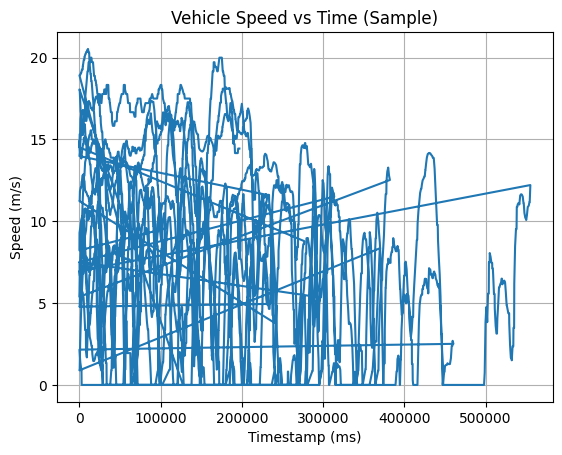

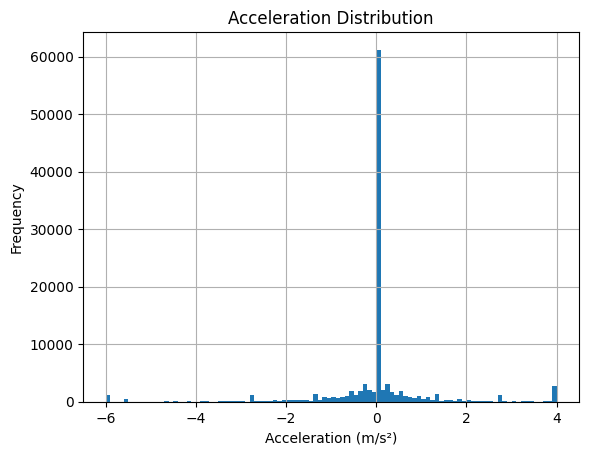

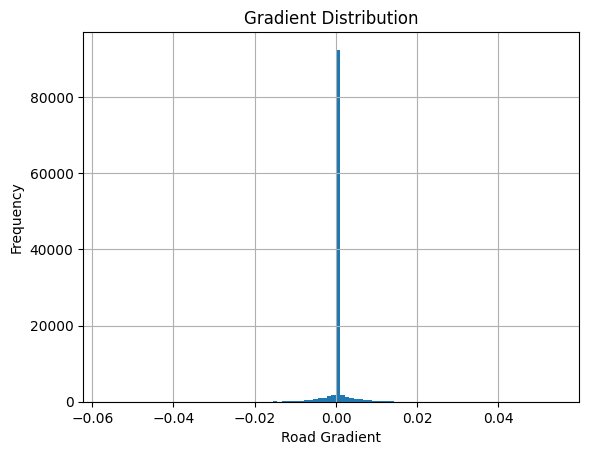

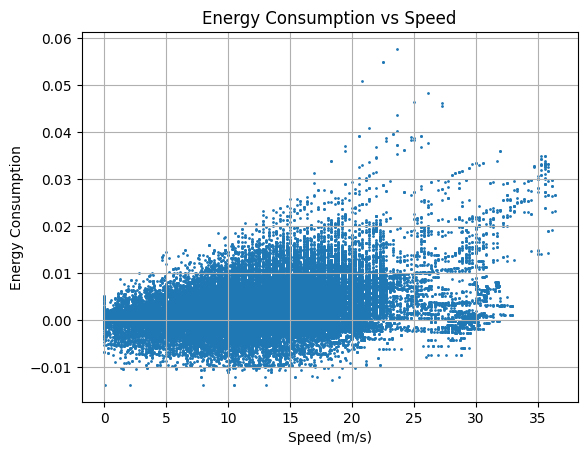

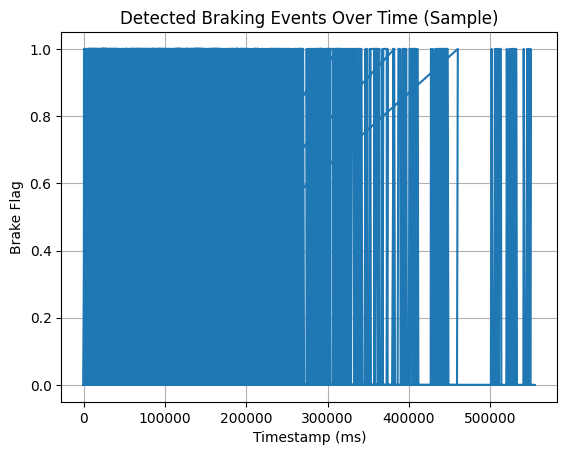

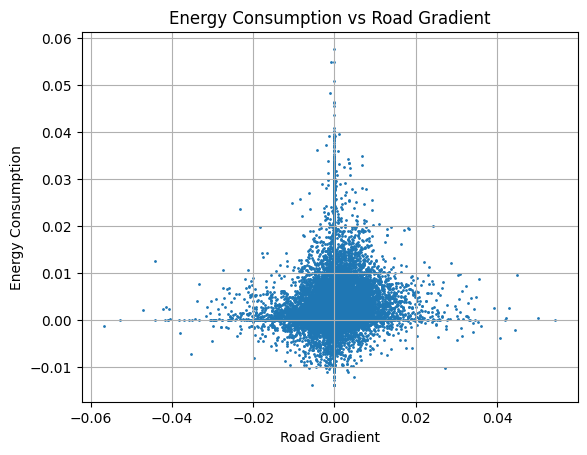

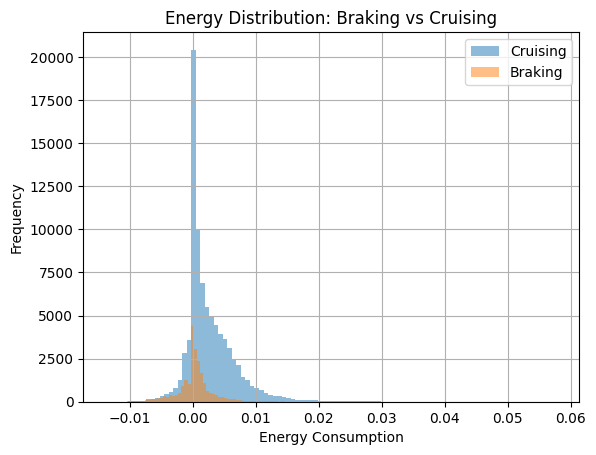

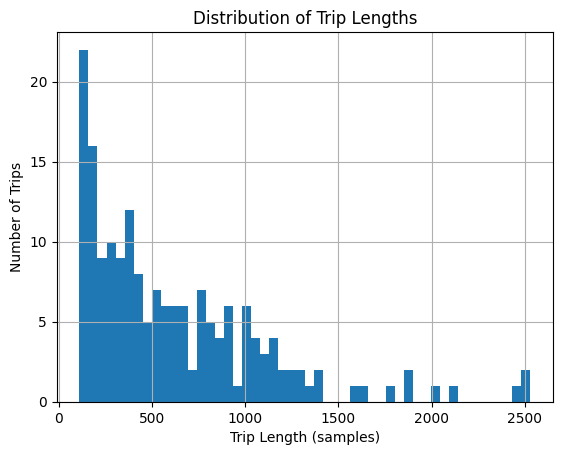

Number of trips: 177
Median trip length: 459.0


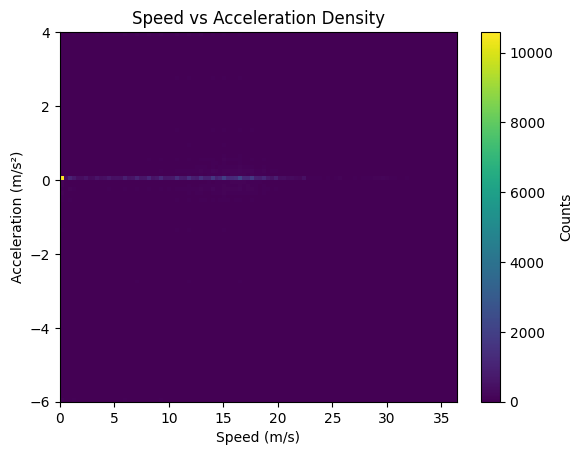

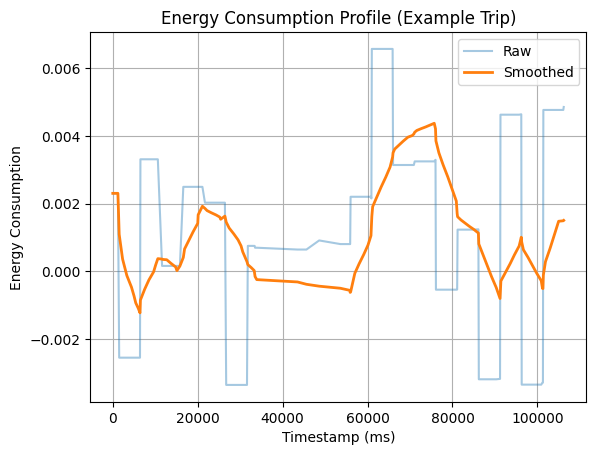

 Full EDA complete.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# LOAD CLEAN DATA

df = pd.read_csv("clean_eved/eVED_171101_week_clean.csv")

print("Total rows:", len(df))

# take sample for time-series plots (for clarity)
sample_df = df.iloc[:5000]


# 1️ SPEED vs TIME

plt.figure()
plt.plot(sample_df["Timestamp(ms)"], sample_df["speed_mps"])
plt.xlabel("Timestamp (ms)")
plt.ylabel("Speed (m/s)")
plt.title("Vehicle Speed vs Time (Sample)")
plt.grid(True)
plt.show()


# 2️ ACCELERATION DISTRIBUTION

plt.figure()
plt.hist(df["acceleration"], bins=100)
plt.xlabel("Acceleration (m/s²)")
plt.ylabel("Frequency")
plt.title("Acceleration Distribution")
plt.grid(True)
plt.show()


# 3️ GRADIENT DISTRIBUTION

plt.figure()
plt.hist(df["Gradient"].dropna(), bins=100)
plt.xlabel("Road Gradient")
plt.ylabel("Frequency")
plt.title("Gradient Distribution")
plt.grid(True)
plt.show()


# 4️ ENERGY vs SPEED

plt.figure()
plt.scatter(df["speed_mps"], df["Energy_Consumption"], s=1)
plt.xlabel("Speed (m/s)")
plt.ylabel("Energy Consumption")
plt.title("Energy Consumption vs Speed")
plt.grid(True)
plt.show()


# 5 BRAKING EVENTS OVER TIME

plt.figure()
plt.plot(sample_df["Timestamp(ms)"], sample_df["brake_flag"])
plt.xlabel("Timestamp (ms)")
plt.ylabel("Brake Flag")
plt.title("Detected Braking Events Over Time (Sample)")
plt.grid(True)
plt.show()


# 6️ ENERGY vs GRADIENT IMPORTANT

plt.figure()
plt.scatter(df['Gradient'], df['Energy_Consumption'], s=1)
plt.xlabel("Road Gradient")
plt.ylabel("Energy Consumption")
plt.title("Energy Consumption vs Road Gradient")
plt.grid(True)
plt.show()


# 7️ BRAKING vs CRUISING ENERGY 

plt.figure()

brake_energy = df[df['brake_flag'] == 1]['Energy_Consumption']
cruise_energy = df[df['brake_flag'] == 0]['Energy_Consumption']

plt.hist(cruise_energy, bins=100, alpha=0.5, label="Cruising")
plt.hist(brake_energy, bins=100, alpha=0.5, label="Braking")

plt.xlabel("Energy Consumption")
plt.ylabel("Frequency")
plt.title("Energy Distribution: Braking vs Cruising")
plt.legend()
plt.grid(True)
plt.show()


# 8️ TRIP LENGTH DISTRIBUTION 
# 
trip_lengths = df.groupby(['VehId', 'Trip']).size()

plt.figure()
plt.hist(trip_lengths, bins=50)
plt.xlabel("Trip Length (samples)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Lengths")
plt.grid(True)
plt.show()

print("Number of trips:", len(trip_lengths))
print("Median trip length:", trip_lengths.median())


# 9️ SPEED vs ACCELERATION HEATMAP 

plt.figure()

plt.hist2d(
    df['speed_mps'],
    df['acceleration'],
    bins=100
)

plt.xlabel("Speed (m/s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Speed vs Acceleration Density")
plt.colorbar(label="Counts")
plt.show()


#  ROLLING ENERGY PROFILE  TIME SERIES

example_trip = df[
    (df['VehId'] == df['VehId'].iloc[0]) &
    (df['Trip'] == df['Trip'].iloc[0])
].copy()

example_trip['energy_smooth'] = example_trip['Energy_Consumption'].rolling(
    window=20, min_periods=1
).mean()

plt.figure()
plt.plot(example_trip['Timestamp(ms)'],
         example_trip['Energy_Consumption'],
         alpha=0.4,
         label="Raw")

plt.plot(example_trip['Timestamp(ms)'],
         example_trip['energy_smooth'],
         linewidth=2,
         label="Smoothed")

plt.xlabel("Timestamp (ms)")
plt.ylabel("Energy Consumption")
plt.title("Energy Consumption Profile (Example Trip)")
plt.legend()
plt.grid(True)
plt.show()

print(" Full EDA complete.")

Some More EDA

In [8]:
import pandas as pd

df = pd.read_csv("clean_eved/eVED_171101_week_clean.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nBasic Statistics:")
print(df.describe())

Shape: (109459, 13)

Columns:
Index(['VehId', 'Trip', 'Timestamp(ms)', 'Vehicle Speed[km/h]', 'Gradient',
       'Elevation Smoothed[m]', 'Energy_Consumption', 'Speed Limit[km/h]',
       'speed_mps', 'dt', 'acceleration', 'brake_flag', 'stop_flag'],
      dtype='object')

Data Types:
VehId                    float64
Trip                     float64
Timestamp(ms)            float64
Vehicle Speed[km/h]      float64
Gradient                 float64
Elevation Smoothed[m]    float64
Energy_Consumption       float64
Speed Limit[km/h]         object
speed_mps                float64
dt                       float64
acceleration             float64
brake_flag                 int64
stop_flag                  int64
dtype: object

Missing values:
VehId                       0
Trip                        0
Timestamp(ms)               0
Vehicle Speed[km/h]         0
Gradient                 2001
Elevation Smoothed[m]       0
Energy_Consumption          0
Speed Limit[km/h]        1279
speed_mps     

In [9]:
print("Unique vehicles:", df["VehId"].nunique())
print("Unique trips:", df["Trip"].nunique())

Unique vehicles: 62
Unique trips: 161


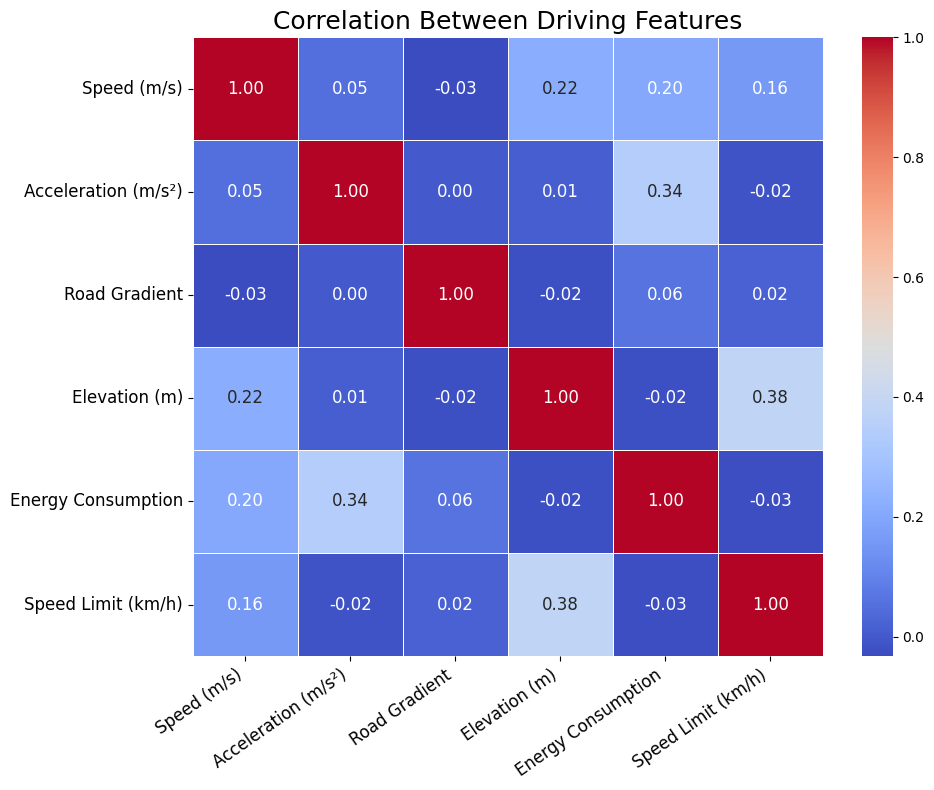

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("clean_eved/eVED_171101_week_clean.csv")

# clean speed limit column
df['Speed Limit[km/h]'] = df['Speed Limit[km/h]'].astype(str).str.split('-').str[0]
df['Speed Limit[km/h]'] = pd.to_numeric(df['Speed Limit[km/h]'], errors='coerce')

cols = [
    'speed_mps',
    'acceleration',
    'Gradient',
    'Elevation Smoothed[m]',
    'Energy_Consumption',
    'Speed Limit[km/h]'
]

corr = df[cols].corr()

# rename for poster
labels = [
    "Speed (m/s)",
    "Acceleration (m/s²)",
    "Road Gradient",
    "Elevation (m)",
    "Energy Consumption",
    "Speed Limit (km/h)"
]

corr.index = labels
corr.columns = labels

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":12}
)

plt.title("Correlation Between Driving Features", fontsize=18)
plt.xticks(rotation=35, ha="right", fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

# save high resolution for poster
plt.savefig("feature_correlation_matrix.png", dpi=400)

plt.show()

# LSTM model 

## Feature Extraction for LSTM

In [12]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

# PARAMETERS

CLEAN_FOLDER = "clean_eved"
WINDOW = 20

FEATURES = [
    'speed_mps',
    'acceleration',
    'Gradient',
    'brake_flag',
    'stop_flag',
    'Speed Limit[km/h]'
]

TARGET = 'Energy_Consumption'


# MULTI-FILE WINDOW BUILDING


files = [f for f in os.listdir(CLEAN_FOLDER) if f.endswith(".csv")]
print(f"Found {len(files)} clean files")

X_list = []
y_list = []
trip_id_list = []   #  NEW (for leakage-safe split)

trip_counter = 0

for file in tqdm(files, desc="Processing files"):

    path = os.path.join(CLEAN_FOLDER, file)
    df = pd.read_csv(path, low_memory=False)

    # ---------- SPEED LIMIT CLEAN ----------
    if 'Speed Limit[km/h]' in df.columns:
        df['Speed Limit[km/h]'] = (
            df['Speed Limit[km/h]']
            .astype(str)
            .str.extract(r'(\d+)')[0]
        )

        df['Speed Limit[km/h]'] = pd.to_numeric(
            df['Speed Limit[km/h]'],
            errors='coerce'
        )

        df['Speed Limit[km/h]'] = df['Speed Limit[km/h]'].fillna(
            df['Speed Limit[km/h]'].median()
        )

    # keep only available features
    FEATURES_LOCAL = [f for f in FEATURES if f in df.columns]

    # ---------- TRIP LOOP ----------
    for (veh, trip), trip_df in df.groupby(['VehId', 'Trip']):

        trip_df = trip_df.sort_values('Timestamp(ms)').reset_index(drop=True)

        if len(trip_df) <= WINDOW:
            continue

        data = trip_df[FEATURES_LOCAL].values
        target = trip_df[TARGET].values

        # sliding window
        for i in range(len(trip_df) - WINDOW):
            X_list.append(data[i:i+WINDOW])
            y_list.append(target[i+WINDOW])
            trip_id_list.append(trip_counter)

        trip_counter += 1


# CONVERT TO NUMPY


X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)
trip_ids = np.array(trip_id_list)

# ---------- NaN/Inf FILTER ----------
mask = (
    ~np.isnan(X).any(axis=(1,2)) &
    ~np.isnan(y) &
    ~np.isinf(X).any(axis=(1,2)) &
    ~np.isinf(y)
)

X = X[mask]
y = y[mask]
trip_ids = trip_ids[mask]

print(" After NaN filtering")
print("\n Windowing complete")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique trips:", len(np.unique(trip_ids)))


Found 54 clean files


Processing files: 100%|██████████| 54/54 [00:03<00:00, 13.61it/s]


 After NaN filtering

 Windowing complete
X shape: (371672, 20, 6)
y shape: (371672,)
Unique trips: 503


## Train/Test/Validation Split

In [13]:
from sklearn.model_selection import train_test_split
import numpy as np

unique_trips = np.unique(trip_ids)

train_trips, temp_trips = train_test_split(
    unique_trips, test_size=0.30, random_state=42
)

val_trips, test_trips = train_test_split(
    temp_trips, test_size=0.50, random_state=42
)

def get_mask(trips):
    return np.isin(trip_ids, trips)

X_train, y_train = X[get_mask(train_trips)], y[get_mask(train_trips)]
X_val,   y_val   = X[get_mask(val_trips)],   y[get_mask(val_trips)]
X_test,  y_test  = X[get_mask(test_trips)],  y[get_mask(test_trips)]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (256040, 20, 6)
Val: (56080, 20, 6)
Test: (59552, 20, 6)


feature normalization

In [14]:
from sklearn.preprocessing import StandardScaler

# get feature dimension
n_features = X_train.shape[2]

scaler = StandardScaler()

# reshape for scaler (2D required)
X_train_2d = X_train.reshape(-1, n_features)
X_val_2d   = X_val.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

# fit ONLY on training data
scaler.fit(X_train_2d)

# transform
X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)

print(" Scaling complete")

 Scaling complete


converting np arrays to torch tensors 

In [15]:
import torch

# convert to float32 tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Torch tensors ready")
print("Train tensor:", X_train_t.shape)

Torch tensors ready
Train tensor: torch.Size([256040, 20, 6])


dataloader setup

In [16]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 512

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

print("DataLoaders ready")

DataLoaders ready


## Defining model

In [17]:
import torch.nn as nn

class EnergyLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        
        # take last timestep
        out = out[:, -1, :]
        
        out = self.fc(out)
        return out

## Training setup

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EnergyLSTM(input_size=X_train.shape[2]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Using device:", device)

Using device: cuda


## Training loop

In [19]:
import time

In [20]:
EPOCHS = 15
start=time.time()
for epoch in range(EPOCHS):
    
    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
end =time.time()
print(f"Training time:{end-start:.2f} seconds")

Epoch 1/15 | Train Loss: 0.000008 | Val Loss: 0.000003
Epoch 2/15 | Train Loss: 0.000004 | Val Loss: 0.000003
Epoch 3/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 4/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 5/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 6/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 7/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 8/15 | Train Loss: 0.000003 | Val Loss: 0.000004
Epoch 9/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 10/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 11/15 | Train Loss: 0.000003 | Val Loss: 0.000004
Epoch 12/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 13/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 14/15 | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch 15/15 | Train Loss: 0.000003 | Val Loss: 0.000005
Training time:123.11 seconds


# test evaluation 

In [12]:
model.eval()
test_loss = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss = criterion(preds, yb)
        test_loss += loss.item()

test_loss /= len(test_loader)

print("\n Test MSE:", test_loss)
print("Test RMSE:", test_loss**0.5)


checkpoint = {
    "model_state": model.state_dict(),
    "scaler": scaler,
    "window": WINDOW,
    "features": FEATURES
}

torch.save(checkpoint, "energy_lstm_checkpoint.pt")
print("Checkpoint saved.")





 Test MSE: 1.0072919703060286e-05
Test RMSE: 0.0031737863354454545
Checkpoint saved.


In [13]:
print(df['Energy_Consumption'].describe())

count    236215.000000
mean          0.002223
std           0.003969
min          -0.015000
25%           0.000045
50%           0.000987
75%           0.003594
max           0.073137
Name: Energy_Consumption, dtype: float64


# Regen Energy Consumption 

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("clean_eved/eVED_171101_week_clean.csv")

#  separate positive and negative energy 
df["energy_positive"] = df["Energy_Consumption"].clip(lower=0)
df["energy_regen"] = df["Energy_Consumption"].clip(upper=0).abs()

#  trip-wise aggregation 
trip_energy = df.groupby(["VehId", "Trip"]).agg({
    "energy_positive": "sum",
    "energy_regen": "sum"
}).reset_index()

#  regen efficiency 
trip_energy["regen_efficiency"] = (
    trip_energy["energy_regen"] /
    (trip_energy["energy_positive"] + 1e-9)
)

print(trip_energy.describe())

            VehId         Trip  energy_positive  energy_regen  \
count  177.000000   177.000000       177.000000    177.000000   
mean   383.355932   768.570621         1.573706      0.218999   
std    149.829611   414.673087         1.440348      0.387782   
min     10.000000     2.000000         0.075435      0.000000   
25%    292.000000   477.000000         0.610403      0.000000   
50%    402.000000   748.000000         1.110249      0.000000   
75%    494.000000  1065.000000         2.013030      0.270518   
max    601.000000  1892.000000         8.969855      1.790345   

       regen_efficiency  
count        177.000000  
mean           0.213527  
std            0.370439  
min            0.000000  
25%            0.000000  
50%            0.000000  
75%            0.263431  
max            2.075168  


In [11]:
#  compute trip-level gradient 
trip_grad = df.groupby(["VehId", "Trip"])["Gradient"].mean().reset_index()
trip_grad.rename(columns={"Gradient": "trip_gradient"}, inplace=True)

# merge with your trip_energy table
trip_energy = trip_energy.merge(trip_grad, on=["VehId", "Trip"], how="left")

print(trip_energy.head())

   VehId    Trip  energy_positive  energy_regen  regen_efficiency  \
0   10.0  1558.0         0.255051      0.093945          0.368339   
1   10.0  1561.0         1.113292      0.248718          0.223408   
2   10.0  1567.0         0.647573      0.070006          0.108106   
3   10.0  1568.0         0.446842      0.062514          0.139903   
4   10.0  1572.0         1.009139      0.178720          0.177101   

   trip_gradient  
0      -0.000365  
1       0.000090  
2       0.000237  
3      -0.000070  
4       0.000067  


In [12]:
import numpy as np

plot_df = trip_energy.copy()

# remove crazy efficiency values
plot_df = plot_df[
    (plot_df["regen_efficiency"] >= 0) &
    (plot_df["regen_efficiency"] <= 1)
]

# drop NaNs
plot_df = plot_df.dropna(subset=["trip_gradient", "regen_efficiency"])

print("Trips used:", len(plot_df))

Trips used: 168


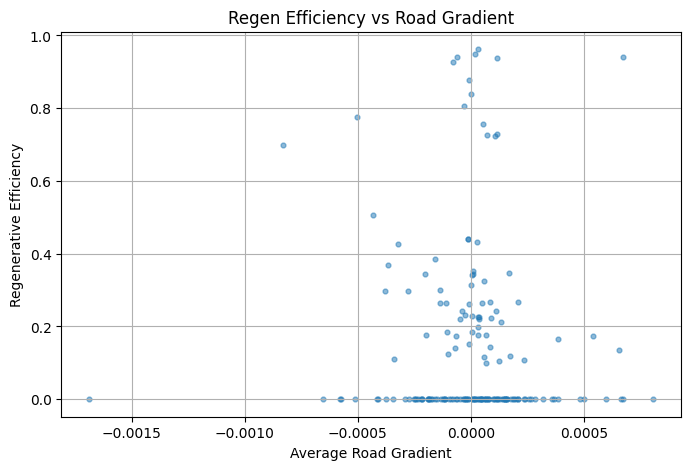

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    plot_df["trip_gradient"],
    plot_df["regen_efficiency"],
    s=12,
    alpha=0.5
)

plt.xlabel("Average Road Gradient")
plt.ylabel("Regenerative Efficiency")
plt.title("Regen Efficiency vs Road Gradient")
plt.grid(True)

plt.show()